In [1]:
import os
import subprocess
import torch

!nvidia-smi

def get_free_gpu():
    """Queries nvidia-smi to find the GPU with the lowest memory usage."""
    try:
        result = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,nounits,noheader"], 
            encoding='utf-8'
        )
        memory_used = [int(x.strip()) for x in result.strip().split('\n')]
        best_gpu_idx = memory_used.index(min(memory_used))
        print(f"[SYSTEM] GPU State (MB used): {memory_used}")
        print(f"[SYSTEM] Automatically claiming GPU {best_gpu_idx}")
        return str(best_gpu_idx)
    except Exception as e:
        print(f"[WARNING] Could not query nvidia-smi: {e}. Defaulting to GPU 0.")
        return "0"

# 1. LOCK THE GPU BEFORE INITIALIZING OTHER LOGIC
os.environ["CUDA_VISIBLE_DEVICES"] = get_free_gpu()

print(f"[SYSTEM] PyTorch initialized. Visible GPUs: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"[SYSTEM] Active Device: {torch.cuda.get_device_name(0)}")
    

Mon Mar 23 19:29:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A4500               Off |   00000000:3B:00.0 Off |                  Off |
| 30%   39C    P8              8W /  200W |    7432MiB /  20470MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch.nn as nn
import torch.optim as optim
import numpy as np
import webdataset as wds
import json
import time
from pathlib import Path
from tqdm.notebook import tqdm

# ROBUST PATHING (Resolves the ~ to your absolute home directory)
user_prefix = input("Enter trial prefix (e.g., tcn_v1) [Press Enter for default 'unknown_trial']: ").strip()
TRIAL_PREFIX = user_prefix if user_prefix else "unknown_trial"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOCAL_SHARDS_DIR = Path(os.path.expanduser("~/Capstone/Implementation/data/mit-supercloud-dataset/gpu/dual_gpu_0000_parquet_to_0019_parquet_cleaned_split_shards"))
SAVE_DIR = Path(os.path.expanduser(f"~/Capstone/Implementation/models/{TRIAL_PREFIX}"))
SAVE_DIR.mkdir(parents=True, exist_ok=True)
SCALARS_PATH = LOCAL_SHARDS_DIR / "normalization_scalars.json"

# Load Scalars
with open(SCALARS_PATH, 'r') as f:
    scalars = json.load(f)

# Print the contents of normalization_scalars.json nicely
print("\n[DATA] Contents of normalization_scalars.json:")
print(f"[DATA] \n{json.dumps(scalars, indent=4)}")

# Setup Tensors for normalization
mins = torch.tensor([scalars['global_minimums'][c] for c in scalars['feature_order']], device=device)
maxs = torch.tensor([scalars['global_maximums'][c] for c in scalars['feature_order']], device=device)
ranges = maxs - mins
ranges[ranges == 0] = 1.0

print(f"\n[TRAINING] Starting Trial : {TRIAL_PREFIX}")

# Strip the home directory out of the path for a cleaner print
clean_save_path = str(SAVE_DIR).replace(os.path.expanduser("~"), "")

print(f"\n[SYSTEM] Data Paths verified. Checkpoint directory ready at {clean_save_path}.")


Enter trial prefix (e.g., tcn_v1) [Press Enter for default 'unknown_trial']:  tcn_v1



[DATA] Contents of normalization_scalars.json:
[DATA] 
{
    "global_minimums": {
        "power_draw_gpu_0_W": 21.81,
        "power_draw_gpu_1_W": 22.78,
        "utilization_gpu_0_pct": 0.0,
        "utilization_gpu_1_pct": 0.0,
        "temperature_gpu_0": 23.0,
        "temperature_gpu_1": 22.0
    },
    "global_maximums": {
        "power_draw_gpu_0_W": 331.08,
        "power_draw_gpu_1_W": 328.86,
        "utilization_gpu_0_pct": 100.0,
        "utilization_gpu_1_pct": 100.0,
        "temperature_gpu_0": 83.0,
        "temperature_gpu_1": 84.0
    },
    "feature_order": [
        "power_draw_gpu_0_W",
        "power_draw_gpu_1_W",
        "utilization_gpu_0_pct",
        "utilization_gpu_1_pct",
        "temperature_gpu_0",
        "temperature_gpu_1"
    ]
}

[TRAINING] Starting Trial : tcn_v1

[SYSTEM] Data Paths verified. Checkpoint directory ready at /Capstone/Implementation/models/tcn_v1.


In [3]:
# Make sure to run 07_calculate_exact_batches.py and update these values according to the output
BATCH_SIZE = 16384
TOTAL_TRAIN_BATCHES = 10407 
TOTAL_VAL_BATCHES = 1198
NUM_WORKERS = 8

# Index resolution
IDX_P0, IDX_P1 = 0, 1
IDX_T0, IDX_T1 = 4, 5

# Empirically derived physical parameters
EMPIRICAL = {
    "C0": 143.22, "C1": 140.25,
    "h0": 4.8713, "h1": 5.3871,
    "k01": 0.078038, "k10": 0.028120,
    "q0": 15.0, "q1": 15.0
}

# The Lean Trial 02 Architecture [32, 64, 128]
class DilatedTCN(nn.Module):
    def __init__(self, num_inputs=6, num_channels=[32, 64, 128], kernel_size=3):
        super(DilatedTCN, self).__init__()
        layers = []
        in_channels = num_inputs
        for i, out_channels in enumerate(num_channels):
            dilation_size = 2 ** i
            padding = (kernel_size - 1) * dilation_size // 2
            layers += [
                nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation_size),
                nn.ReLU(),
                nn.BatchNorm1d(out_channels)
            ]
            in_channels = out_channels
        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], 2)

    def forward(self, x):
        x = x.transpose(1, 2)
        out = self.tcn(x)
        return self.fc(out[:, :, -1])

class PINNEngine(nn.Module):
    def __init__(self):
        super(PINNEngine, self).__init__()
        self.tcn = DilatedTCN()
        self.raw_params = nn.ParameterDict({k: nn.Parameter(torch.tensor(0.0)) for k in EMPIRICAL.keys()})
        self.T_amb = 30.5

    def get_bounded_physics(self):
        phys = {}
        for k, exact_val in EMPIRICAL.items():
            min_bound = exact_val * 0.90
            max_bound = exact_val * 1.10
            phys[k] = min_bound + (max_bound - min_bound) * torch.sigmoid(self.raw_params[k])
        return phys

    def forward(self, x):
        return self.tcn(x)

model = PINNEngine().to(device)

# --- High-Throughput Dataloader ---
def make_windows_vectorized(src, window_size=50, stride=10):
    for key, npy_array in src:
        n_rows = npy_array.shape[0]
        if n_rows < window_size: continue
        windows = np.lib.stride_tricks.sliding_window_view(npy_array, window_shape=window_size, axis=0)
        windows = np.swapaxes(windows, 1, 2)
        windows = windows[::stride]
        for w in windows: yield key, w

def create_dataloader(shard_list, is_train=True):
    shard_shuffle_val = 100 if is_train else 0
    dataset = wds.WebDataset(shard_list, shardshuffle=shard_shuffle_val).decode()
    dataset = dataset.to_tuple("__key__", "data.npy")
    dataset = dataset.compose(lambda src: make_windows_vectorized(src, window_size=50, stride=10))
    if is_train:
        dataset = dataset.shuffle(5000)
    dataset = dataset.batched(BATCH_SIZE)
    
    # THE HPC ADVANTAGE: NUM_WORKERS Workers, Pinned Memory, Prefetching
    return torch.utils.data.DataLoader(
        dataset, batch_size=None, 
        num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2
    )

train_files = [str(p) for p in sorted((LOCAL_SHARDS_DIR / "train").glob("*.tar"))]
val_files = [str(p) for p in sorted((LOCAL_SHARDS_DIR / "val").glob("*.tar"))]

train_loader = create_dataloader(train_files, is_train=True)
val_loader = create_dataloader(val_files, is_train=False)

print(f"[SYSTEM] HPC Dataloaders configured with {NUM_WORKERS} Workers.")


[SYSTEM] HPC Dataloaders configured with 8 Workers.


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import webdataset as wds
import json
import time
import os
import csv
from pathlib import Path
from tqdm.notebook import tqdm
import subprocess

# Parameters
EPOCHS = 50
LEARNING_RATE = 1e-3
LAMBDA_DATA = 1.0
LAMBDA_PHYS = 0.5
DT = 0.1

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
mse_loss = nn.MSELoss()
best_val_loss = float('inf')

# INITIALIZE THE AMP SCALER
scaler = torch.amp.GradScaler('cuda')

# LOGGING INFRASTRUCTURE SETUP
gpu_log_path = SAVE_DIR / f"{TRIAL_PREFIX}_gpu_stats.csv"
epoch_log_path = SAVE_DIR / f"{TRIAL_PREFIX}_epoch_logs.csv"

print(f"\n[SYSTEM] Continuous nvidia-smi logs saving to: {gpu_log_path.name}")
print(f"[SYSTEM] Granular Epoch metrics saving to: {epoch_log_path.name}")

# Start nvidia-smi background logger
gpu_log_file = open(gpu_log_path, "w")
gpu_logger = subprocess.Popen(
    [
        "nvidia-smi", 
        "--query-gpu=timestamp,utilization.gpu,utilization.memory,memory.used,temperature.gpu", 
        "--format=csv", 
        "-l", "5"
    ],
    stdout=gpu_log_file,
    stderr=subprocess.STDOUT
)

# Start Epoch CSV logger
epoch_log_file = open(epoch_log_path, mode='w', newline='')
epoch_writer = csv.writer(epoch_log_file)
headers = [
    'Epoch', 'Train_Loss_Total', 'Train_Loss_Data', 'Train_Loss_Phys',
    'Val_Loss_Total', 'Val_Loss_Data', 'Val_Loss_Phys',
    'C0', 'C1', 'h0', 'h1', 'k01', 'k10', 'q0', 'q1'
]
epoch_writer.writerow(headers)

print(f"\n[TRAINING] INITIATING HPC MODEL TRAINING [{TRIAL_PREFIX}]")
print("[TRAINING] Best Models are Flagged by - [*]")

try:
    for epoch in range(1, EPOCHS + 1):
        epoch_start_time = time.time()
        model.train()
        
        # Training Trackers
        total_train_loss = 0.0
        total_train_loss_data = 0.0 
        total_train_loss_phys = 0.0

        train_pbar = tqdm(train_loader, total=TOTAL_TRAIN_BATCHES, desc=f"Epoch {epoch:02d}/{EPOCHS} [Train]", leave=False)

        for batch_idx, (keys, data_block) in enumerate(train_pbar):
            X_seq = data_block[:, :-1, :].to(device)
            Y_true_abs = data_block[:, -1, 4:6].to(device)
            Y_true_norm = (Y_true_abs - mins[4:6]) / ranges[4:6]
            X_norm = (X_seq - mins) / ranges

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                Y_pred_norm = model(X_norm)
                
                # 1. Calculate Data Loss in NORMALIZED space
                loss_data = mse_loss(Y_pred_norm, Y_true_norm)
                
                # 2. Project predictions back to absolute space
                Y_pred_abs = Y_pred_norm * ranges[4:6] + mins[4:6]
                
                # 3. Physics extraction
                X_last_step = X_seq[:, -1, :]
                P0_abs, P1_abs = X_last_step[:, IDX_P0], X_last_step[:, IDX_P1]
                T0_t_abs, T1_t_abs = X_last_step[:, IDX_T0], X_last_step[:, IDX_T1]
                T0_pred_abs, T1_pred_abs = Y_pred_abs[:, 0], Y_pred_abs[:, 1]
            
                phys = model.get_bounded_physics()
                res_0 = ((T0_pred_abs - T0_t_abs) / DT) - (1/phys["C0"]) * (P0_abs + phys["k01"]*P1_abs - phys["h0"]*(T0_t_abs - model.T_amb) + phys["q0"])
                res_1 = ((T1_pred_abs - T1_t_abs) / DT) - (1/phys["C1"]) * (P1_abs + phys["k10"]*P0_abs - phys["h1"]*(T1_t_abs - model.T_amb) + phys["q1"])
            
                zeros = torch.zeros_like(res_0)
                
                # 4. Calculate Physics Loss in ABSOLUTE space
                loss_phys = mse_loss(res_0, zeros) + mse_loss(res_1, zeros)
                
                # 5. Composite Loss
                loss_total = (LAMBDA_DATA * loss_data) + (LAMBDA_PHYS * loss_phys)

            # SCALED BACKPROPAGATION
            scaler.scale(loss_total).backward()
            scaler.step(optimizer)
            scaler.update()

            total_train_loss += loss_total.item()
            total_train_loss_data += loss_data.item()
            total_train_loss_phys += loss_phys.item()
            
            train_pbar.set_postfix({"Loss": f"{loss_total.item():.4f}"})

        # Calculate Training Averages
        avg_train_loss = total_train_loss / TOTAL_TRAIN_BATCHES
        avg_train_data = total_train_loss_data / TOTAL_TRAIN_BATCHES
        avg_train_phys = total_train_loss_phys / TOTAL_TRAIN_BATCHES

        # VALIDATION LOOP
        model.eval()
        
        # Validation Trackers
        total_val_loss = 0.0
        total_val_loss_data = 0.0
        total_val_loss_phys = 0.0
        
        val_pbar = tqdm(val_loader, total=TOTAL_VAL_BATCHES, desc="Validation", leave=False)

        with torch.no_grad():
            for batch_idx, (keys, val_block) in enumerate(val_pbar):
                X_val = val_block[:, :-1, :].to(device)
                Y_val_true_abs = val_block[:, -1, 4:6].to(device)
                Y_val_true_norm = (Y_val_true_abs - mins[4:6]) / ranges[4:6]
                X_val_norm = (X_val - mins) / ranges
                
                with torch.amp.autocast('cuda'):
                    Y_val_pred_norm = model(X_val_norm)
                    loss_data_v = mse_loss(Y_val_pred_norm, Y_val_true_norm)

                    Y_val_pred_abs = Y_val_pred_norm * ranges[4:6] + mins[4:6]
                    X_val_last_step = X_val[:, -1, :]

                    P0_abs_v, P1_abs_v = X_val_last_step[:, IDX_P0], X_val_last_step[:, IDX_P1]
                    T0_t_abs_v, T1_t_abs_v = X_val_last_step[:, IDX_T0], X_val_last_step[:, IDX_T1]
                    T0_pred_abs_v, T1_pred_abs_v = Y_val_pred_abs[:, 0], Y_val_pred_abs[:, 1]

                    phys_v = model.get_bounded_physics()
                    res_0_v = ((T0_pred_abs_v - T0_t_abs_v) / DT) - (1/phys_v["C0"]) * (P0_abs_v + phys_v["k01"]*P1_abs_v - phys_v["h0"]*(T0_t_abs_v - model.T_amb) + phys_v["q0"])
                    res_1_v = ((T1_pred_abs_v - T1_t_abs_v) / DT) - (1/phys_v["C1"]) * (P1_abs_v + phys_v["k10"]*P0_abs_v - phys_v["h1"]*(T1_t_abs_v - model.T_amb) + phys_v["q1"])

                    zeros_v = torch.zeros_like(res_0_v)
                    loss_phys_v = mse_loss(res_0_v, zeros_v) + mse_loss(res_1_v, zeros_v)
                    
                    loss_total_v = (LAMBDA_DATA * loss_data_v) + (LAMBDA_PHYS * loss_phys_v)
                    
                    total_val_loss += loss_total_v.item()
                    total_val_loss_data += loss_data_v.item()
                    total_val_loss_phys += loss_phys_v.item()

        # Calculate Validation Averages
        avg_val_loss = total_val_loss / TOTAL_VAL_BATCHES
        avg_val_data = total_val_loss_data / TOTAL_VAL_BATCHES
        avg_val_phys = total_val_loss_phys / TOTAL_VAL_BATCHES
        
        epoch_duration = time.time() - epoch_start_time

        # WRITE TO EPOCH CSV LOG
        current_phys = model.get_bounded_physics()
        epoch_row = [
            epoch, avg_train_loss, avg_train_data, avg_train_phys,
            avg_val_loss, avg_val_data, avg_val_phys,
            current_phys['C0'].item(), current_phys['C1'].item(),
            current_phys['h0'].item(), current_phys['h1'].item(),
            current_phys['k01'].item(), current_phys['k10'].item(),
            current_phys['q0'].item(), current_phys['q1'].item()
        ]
        epoch_writer.writerow(epoch_row)
        epoch_log_file.flush() # Ensure it writes to disk immediately

        # MATHEMATICAL WALKTHROUGH (END OF EPOCH 1)
        if epoch == 1:
            print("\n[MATH] " + "="*80)
            print("[MATH] >>> EPOCH 1: COMPLETE MATHEMATICAL WALKTHROUGH & PROOF <<<")
            print("[MATH] " + "="*80)
            
            print("[MATH] --- PART 1: AGGREGATE TRAINING LOSS PROOF ---")
            print(f"[MATH] LAMBDA_DATA: {LAMBDA_DATA} | LAMBDA_PHYS: {LAMBDA_PHYS}")
            print(f"[MATH] Avg Train Data Loss : {avg_train_data:.8f}")
            print(f"[MATH] Avg Train Phys Loss : {avg_train_phys:.8f}")
            calc_train = (LAMBDA_DATA * avg_train_data) + (LAMBDA_PHYS * avg_train_phys)
            print(f"[MATH] Math: ({LAMBDA_DATA} * {avg_train_data:.8f}) + ({LAMBDA_PHYS} * {avg_train_phys:.8f}) = {calc_train:.8f}")
            print(f"[MATH] Printed Train Loss  : {avg_train_loss:.8f}")
            
            print("\n[MATH] --- PART 2: AGGREGATE VALIDATION LOSS PROOF ---")
            print(f"[MATH] Avg Val Data Loss   : {avg_val_data:.8f}")
            print(f"[MATH] Avg Val Phys Loss   : {avg_val_phys:.8f}")
            calc_val = (LAMBDA_DATA * avg_val_data) + (LAMBDA_PHYS * avg_val_phys)
            print(f"[MATH] Math: ({LAMBDA_DATA} * {avg_val_data:.8f}) + ({LAMBDA_PHYS} * {avg_val_phys:.8f}) = {calc_val:.8f}")
            print(f"[MATH] Printed Val Loss    : {avg_val_loss:.8f}")
            
            print("\n[MATH] --- PART 3: ROW-LEVEL PHYSICS RESIDUAL DISSECTION ---")
            print("[MATH] To manually verify the physics logic, we extract Row 0 from the final Validation batch:")
            
            p0, p1 = P0_abs_v[0].item(), P1_abs_v[0].item()
            t0_t, t1_t = T0_t_abs_v[0].item(), T1_t_abs_v[0].item()
            t0_p, t1_p = T0_pred_abs_v[0].item(), T1_pred_abs_v[0].item()
            
            print(f"[MATH] Inputs   -> P0: {p0:.4f}, P1: {p1:.4f}")
            print(f"[MATH] Targets  -> T0_t: {t0_t:.4f}, T1_t: {t1_t:.4f}")
            print(f"[MATH] Predicts -> T0_pred: {t0_p:.4f}, T1_pred: {t1_p:.4f}")
            print("[MATH] Constants:")
            for k, v in current_phys.items():
                print(f"[MATH]   {k}: {v.item():.4f}")
                
            print("\n[MATH] Equation res_0:")
            print(f"[MATH] res_0 = (({t0_p:.4f} - {t0_t:.4f}) / {DT}) - (1/{current_phys['C0'].item():.4f}) * ({p0:.4f} + {current_phys['k01'].item():.4f}*{p1:.4f} - {current_phys['h0'].item():.4f}*({t0_t:.4f} - {model.T_amb}) + {current_phys['q0'].item():.4f})")
            r0_val = res_0_v[0].item()
            print(f"[MATH] Actual Tensor Output (res_0) = {r0_val:.6f}")
            
            print("\n[MATH] Equation res_1:")
            print(f"[MATH] res_1 = (({t1_p:.4f} - {t1_t:.4f}) / {DT}) - (1/{current_phys['C1'].item():.4f}) * ({p1:.4f} + {current_phys['k10'].item():.4f}*{p0:.4f} - {current_phys['h1'].item():.4f}*({t1_t:.4f} - {model.T_amb}) + {current_phys['q1'].item():.4f})")
            r1_val = res_1_v[0].item()
            print(f"[MATH] Actual Tensor Output (res_1) = {r1_val:.6f}")
            
            print("\n[MATH] --- PART 4: THE SQUARED PENALTY (MSE) ---")
            print("[MATH] PyTorch's mse_loss squares these residuals because the target is zero.")
            print(f"[MATH] res_0 squared : ({r0_val:.6f})^2 = {r0_val**2:.6f}")
            print(f"[MATH] res_1 squared : ({r1_val:.6f})^2 = {r1_val**2:.6f}")
            print(f"[MATH] Total Row Physics Penalty : {r0_val**2:.6f} + {r1_val**2:.6f} = {(r0_val**2) + (r1_val**2):.6f}")
            print("[MATH] (Note: The batch loss_phys is the average of this penalty across all 16,384 rows)")
            print("[MATH] " + "="*80 + "\n")

        # SAVING & PRINTING
        best_flag = ""
        checkpoint_state = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
            'torch_rng': torch.get_rng_state()
        }

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(checkpoint_state, SAVE_DIR / f"{TRIAL_PREFIX}_best_model.pt")
            best_flag = "[*]"

        print(f"[TRAINING] Epoch {epoch:02d}/{EPOCHS} | Time: {epoch_duration:.1f}s | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} {best_flag}")

except KeyboardInterrupt:
    print("\n[!] Training manually interrupted. Checkpoints are safe.")
finally:
    gpu_logger.terminate()
    gpu_log_file.close()
    epoch_log_file.close()
    print(f"[SYSTEM] Background GPU logging terminated. Epoch logs securely saved.")
    


[SYSTEM] Continuous nvidia-smi logs saving to: tcn_v1_gpu_stats.csv
[SYSTEM] Granular Epoch metrics saving to: tcn_v1_epoch_logs.csv

[TRAINING] INITIATING HPC MODEL TRAINING [tcn_v1]
[TRAINING] Best Models are Flagged by - [*]


Epoch 01/50 [Train]:   0%|          | 0/10407 [00:00<?, ?it/s]

Validation:   0%|          | 0/1198 [00:00<?, ?it/s]


[MATH] ================================================================================
[MATH] >>> EPOCH 1: COMPLETE MATHEMATICAL WALKTHROUGH & PROOF <<<
[MATH] ================================================================================
[MATH] --- PART 1: AGGREGATE TRAINING LOSS PROOF ---
[MATH] LAMBDA_DATA: 1.0 | LAMBDA_PHYS: 0.5
[MATH] Avg Train Data Loss : 0.00550831
[MATH] Avg Train Phys Loss : 4075.99744163
[MATH] Math: (1.0 * 0.00550831) + (0.5 * 4075.99744163) = 2038.00422913
[MATH] Printed Train Loss  : 2038.00422860

[MATH] --- PART 2: AGGREGATE VALIDATION LOSS PROOF ---
[MATH] Avg Val Data Loss   : 0.00388441
[MATH] Avg Val Phys Loss   : 2801.02180264
[MATH] Math: (1.0 * 0.00388441) + (0.5 * 2801.02180264) = 1400.51478573
[MATH] Printed Val Loss    : 1400.51478692

[MATH] --- PART 3: ROW-LEVEL PHYSICS RESIDUAL DISSECTION ---
[MATH] To manually verify the physics logic, we extract Row 0 from the final Validation batch:
[MATH] Inputs   -> P0: 42.1200, P1: 43.4900
[MATH] T

Epoch 02/50 [Train]:   0%|          | 0/10407 [00:00<?, ?it/s]


[!] Training manually interrupted. Checkpoints are safe.
[SYSTEM] Background GPU logging terminated. Epoch logs securely saved.


Enter the Trial Prefix to evaluate (e.g., tcn_v2):  tcn_v1



[SYSTEM] Evaluating Model: /Capstone/Implementation/models/tcn_v1/tcn_v1_best_model.pt
[SYSTEM] Successfully loaded weights from Epoch 1. Val Loss was: inf

[TESTING] ================================================================================
[TESTING] >>> PHASE 1: GLOBAL TEST SET EVALUATION (1-Step-Ahead) <<<
[TESTING] ================================================================================


Testing Global Shards:   0%|          | 0/1359 [00:00<?, ?it/s]


[METRIC] Final Global Test Results:
[METRIC] --- GPU 0 Global Metrics ---
[METRIC] RMSE : 4.0965 °C
[METRIC] MAE  : 3.4194 °C
[METRIC] R^2  : 0.9097

[METRIC] --- GPU 1 Global Metrics ---
[METRIC] RMSE : 2.7577 °C
[METRIC] MAE  : 1.9808 °C
[METRIC] R^2  : 0.9518

[SYSTEM] Rendering Global Scatter Plots...


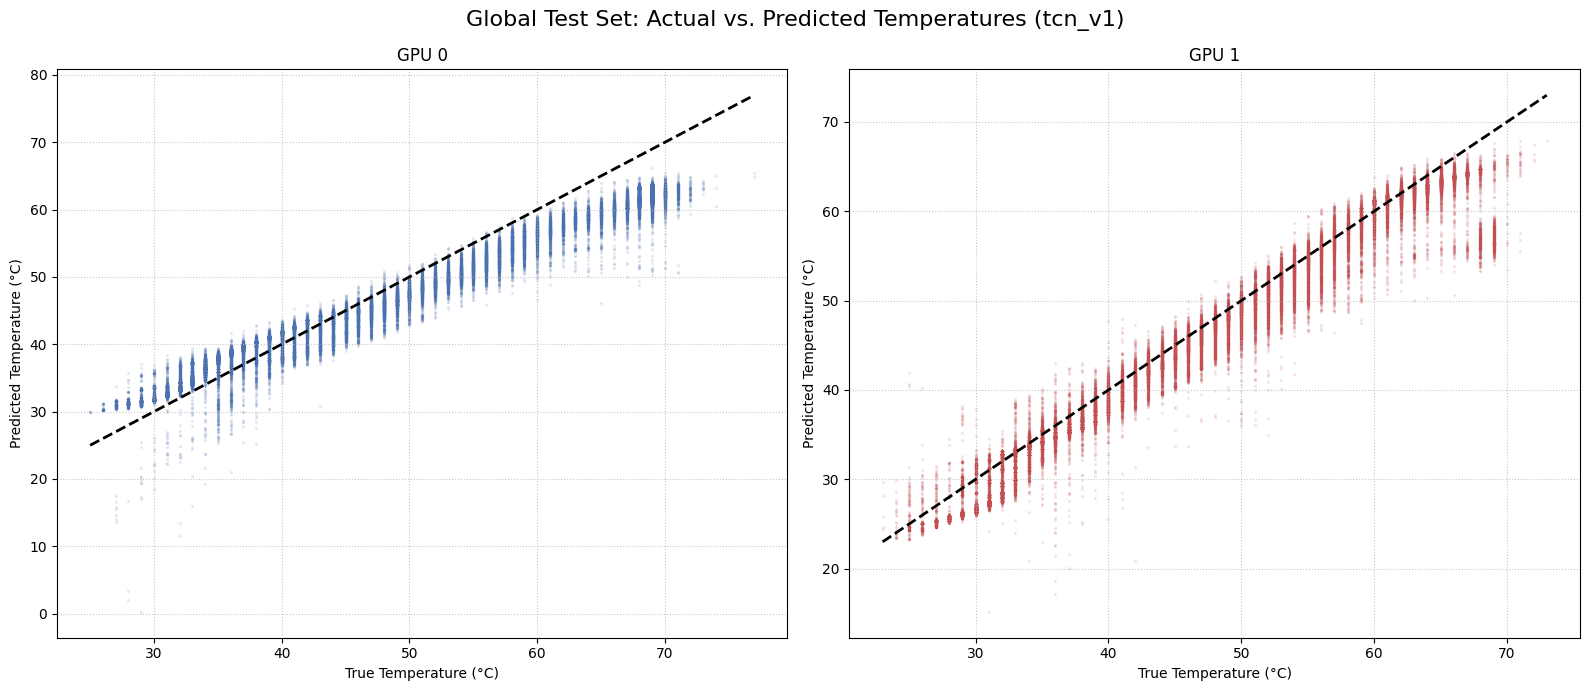

[SYSTEM] Plot saved securely to: tcn_v1_global_scatter.png

[SIMULATION] ================================================================================
[SIMULATION] >>> PHASE 2: AUTOREGRESSIVE JOB SIMULATION <<<
[SIMULATION] ================================================================================

[SIMULATION] Targeting Job File: 58187302949844-r3741709-n851693_cleaned | Timesteps: 10626


Rolling out Trajectory:   0%|          | 0/10576 [00:00<?, ?it/s]

[METRIC] Autoregressive RMSE -> GPU 0: 13.11 °C | GPU 1: 12.63 °C


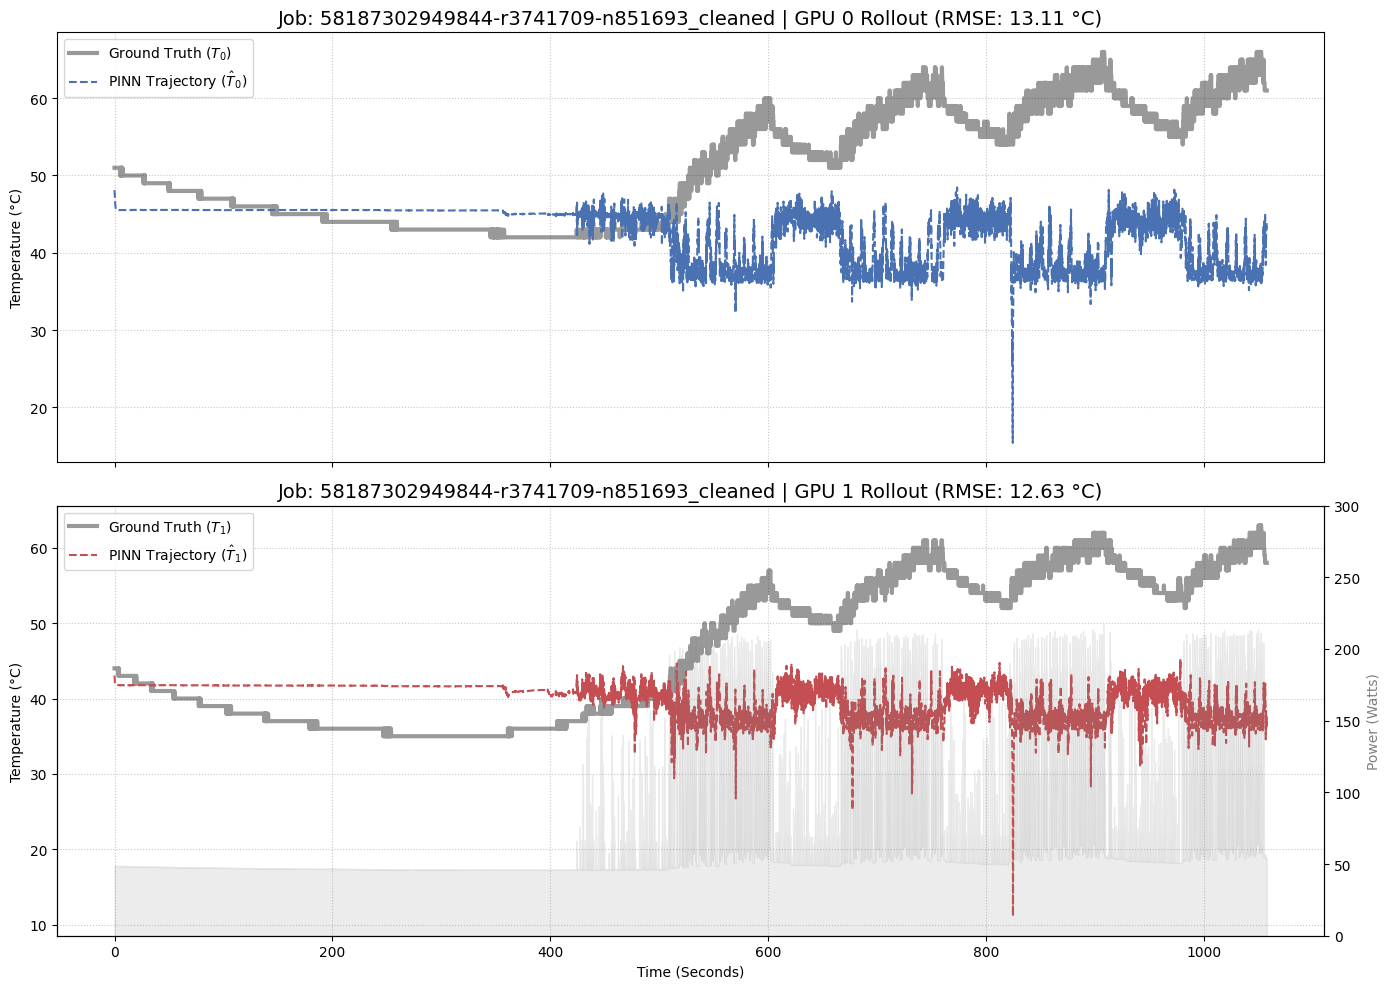

[SYSTEM] Trajectory plot saved securely to: tcn_v1_autoregressive_58187302949844-r3741709-n851693_cleaned.png


In [5]:
import os
import subprocess
import torch
import torch.nn as nn
import numpy as np
import webdataset as wds
import json
import time
import random
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

# 1. HPC HARDWARE ISOLATION & PATHING
def get_free_gpu():
    try:
        result = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,nounits,noheader"], 
            encoding='utf-8'
        )
        memory_used = [int(x.strip()) for x in result.strip().split('\n')]
        best_gpu_idx = memory_used.index(min(memory_used))
        return str(best_gpu_idx)
    except Exception:
        return "0"

os.environ["CUDA_VISIBLE_DEVICES"] = get_free_gpu()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRIAL_PREFIX = input("Enter the Trial Prefix to evaluate (e.g., tcn_v2): ").strip()

# Absolute Pathing
PROJECT_DIR = Path(os.path.expanduser("~/Capstone/Implementation"))
LOCAL_SHARDS_DIR = PROJECT_DIR / "data/mit-supercloud-dataset/gpu/dual_gpu_0000_parquet_to_0019_parquet_cleaned_split_shards"
MODEL_DIR = PROJECT_DIR / f"models/{TRIAL_PREFIX}"
SCALARS_PATH = LOCAL_SHARDS_DIR / "normalization_scalars.json"

MODEL_PATH = MODEL_DIR / f"{TRIAL_PREFIX}_best_model.pt"
display_path = str(MODEL_PATH).replace(os.path.expanduser("~"), "")

print(f"\n[SYSTEM] Evaluating Model: {display_path}")

# Load Scalars
with open(SCALARS_PATH, 'r') as f:
    scalars = json.load(f)

mins = torch.tensor([scalars['global_minimums'][c] for c in scalars['feature_order']], device=device)
maxs = torch.tensor([scalars['global_maximums'][c] for c in scalars['feature_order']], device=device)
ranges = maxs - mins
ranges[ranges == 0] = 1.0

# 2. ARCHITECTURE DEFINITION & WEIGHT INGESTION
EMPIRICAL = {
    "C0": 143.22, "C1": 140.25, "h0": 4.8713, "h1": 5.3871,
    "k01": 0.078038, "k10": 0.028120, "q0": 15.0, "q1": 15.0
}

class DilatedTCN(nn.Module):
    def __init__(self, num_inputs=6, num_channels=[32, 64, 128], kernel_size=3):
        super(DilatedTCN, self).__init__()
        layers = []
        in_channels = num_inputs
        for i, out_channels in enumerate(num_channels):
            dilation_size = 2 ** i
            padding = (kernel_size - 1) * dilation_size // 2
            layers += [
                nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation_size),
                nn.ReLU(),
                nn.BatchNorm1d(out_channels)
            ]
            in_channels = out_channels
        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], 2)

    def forward(self, x):
        x = x.transpose(1, 2)
        out = self.tcn(x)
        return self.fc(out[:, :, -1])

class PINNEngine(nn.Module):
    def __init__(self):
        super(PINNEngine, self).__init__()
        self.tcn = DilatedTCN()
        self.raw_params = nn.ParameterDict({k: nn.Parameter(torch.tensor(0.0)) for k in EMPIRICAL.keys()})
        self.T_amb = 30.5
    def forward(self, x):
        return self.tcn(x)

model = PINNEngine().to(device)

if MODEL_PATH.exists():
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"[SYSTEM] Successfully loaded weights from Epoch {checkpoint['epoch']}. Val Loss was: {checkpoint['best_val_loss']:.6f}")
else:
    raise FileNotFoundError(f"[ERROR] Could not find model at {MODEL_PATH}")

model.eval()

# 3. GLOBAL TEST SET EVALUATION (1-Step-Ahead)
print("\n[TESTING] " + "="*80)
print("[TESTING] >>> PHASE 1: GLOBAL TEST SET EVALUATION (1-Step-Ahead) <<<")
print("[TESTING] " + "="*80)

BATCH_SIZE = 16384
NUM_WORKERS = 8
EXACT_TEST_BATCHES = 1359

def make_windows_vectorized(src, window_size=50, stride=10):
    for key, npy_array in src:
        n_rows = npy_array.shape[0]
        if n_rows < window_size: continue
        windows = np.lib.stride_tricks.sliding_window_view(npy_array, window_shape=window_size, axis=0)
        windows = np.swapaxes(windows, 1, 2)
        windows = windows[::stride]
        for w in windows: yield key, w

test_files = [str(p) for p in sorted((LOCAL_SHARDS_DIR / "test").glob("*.tar"))]
test_dataset = wds.WebDataset(test_files, shardshuffle=0).decode().to_tuple("__key__", "data.npy")
test_dataset = test_dataset.compose(lambda src: make_windows_vectorized(src, window_size=50, stride=10)).batched(BATCH_SIZE)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=None, num_workers=NUM_WORKERS, pin_memory=True)

mse_loss = nn.MSELoss()
total_test_loss = 0.0

all_true_T0, all_pred_T0 = [], []
all_true_T1, all_pred_T1 = [], []

with torch.no_grad():
    for batch_idx, (keys, test_block) in enumerate(tqdm(test_loader, desc="Testing Global Shards", total=EXACT_TEST_BATCHES)):
        X_test = test_block[:, :-1, :].to(device)
        
        # Exact alignment with your fixed training logic
        Y_test_true_abs = test_block[:, -1, 4:6].to(device)
        Y_test_true_norm = (Y_test_true_abs - mins[4:6]) / ranges[4:6]
        
        X_test_norm = (X_test - mins) / ranges
        
        with torch.amp.autocast('cuda'):
            Y_test_pred_norm = model(X_test_norm)
            loss = mse_loss(Y_test_pred_norm, Y_test_true_norm)
            
        total_test_loss += loss.item()

        # Un-normalize for plotting
        Y_pred_abs = Y_test_pred_norm * ranges[4:6] + mins[4:6]
        
        all_true_T0.extend(Y_test_true_abs[:, 0].cpu().numpy())
        all_pred_T0.extend(Y_pred_abs[:, 0].cpu().numpy())
        all_true_T1.extend(Y_test_true_abs[:, 1].cpu().numpy())
        all_pred_T1.extend(Y_pred_abs[:, 1].cpu().numpy())

        # Convert accumulated lists to NumPy arrays for vectorized metric calculation
        true_T0_arr = np.array(all_true_T0)
        pred_T0_arr = np.array(all_pred_T0)
        true_T1_arr = np.array(all_true_T1)
        pred_T1_arr = np.array(all_pred_T1)
        
        def calculate_metrics(y_true, y_pred, gpu_label):
            rmse = np.sqrt(np.mean((y_true - y_pred)**2))
            mae = np.mean(np.abs(y_true - y_pred))
            ss_res = np.sum((y_true - y_pred)**2)
            ss_tot = np.sum((y_true - np.mean(y_true))**2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0
            
            print(f"[METRIC] --- {gpu_label} Global Metrics ---")
            print(f"[METRIC] RMSE : {rmse:.4f} °C")
            print(f"[METRIC] MAE  : {mae:.4f} °C")
            print(f"[METRIC] R^2  : {r2:.4f}\n")
            return rmse, mae, r2

if all_true_T0:
    print("\n[METRIC] Final Global Test Results:")
    calculate_metrics(true_T0_arr, pred_T0_arr, "GPU 0")
    calculate_metrics(true_T1_arr, pred_T1_arr, "GPU 1")

# --- Scatter Plot Rendering ---
print("[SYSTEM] Rendering Global Scatter Plots...")
MAX_POINTS = 50000 
total_points = len(all_true_T0)

if total_points > MAX_POINTS:
    indices = random.sample(range(total_points), MAX_POINTS)
    plot_true_T0, plot_pred_T0 = np.array(all_true_T0)[indices], np.array(all_pred_T0)[indices]
    plot_true_T1, plot_pred_T1 = np.array(all_true_T1)[indices], np.array(all_pred_T1)[indices]
else:
    plot_true_T0, plot_pred_T0 = all_true_T0, all_pred_T0
    plot_true_T1, plot_pred_T1 = all_true_T1, all_pred_T1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"Global Test Set: Actual vs. Predicted Temperatures ({TRIAL_PREFIX})", fontsize=16)

ax1.scatter(plot_true_T0, plot_pred_T0, alpha=0.1, color="#4A72B2", s=2)
ax1.plot([min(plot_true_T0), max(plot_true_T0)], [min(plot_true_T0), max(plot_true_T0)], 'k--', lw=2)
ax1.set_title("GPU 0")
ax1.set_xlabel("True Temperature (°C)")
ax1.set_ylabel("Predicted Temperature (°C)")
ax1.grid(True, linestyle=':', alpha=0.7)

ax2.scatter(plot_true_T1, plot_pred_T1, alpha=0.1, color="#C44E52", s=2)
ax2.plot([min(plot_true_T1), max(plot_true_T1)], [min(plot_true_T1), max(plot_true_T1)], 'k--', lw=2)
ax2.set_title("GPU 1")
ax2.set_xlabel("True Temperature (°C)")
ax2.set_ylabel("Predicted Temperature (°C)")
ax2.grid(True, linestyle=':', alpha=0.7)

plot_path = MODEL_DIR / f"{TRIAL_PREFIX}_global_scatter.png"
plt.tight_layout()
plt.savefig(plot_path, dpi=300)
plt.show()
print(f"[SYSTEM] Plot saved securely to: {plot_path.name}")


# 4. AUTOREGRESSIVE SIMULATOR (Trajectory Rollout)
print("\n[SIMULATION] " + "="*80)
print("[SIMULATION] >>> PHASE 2: AUTOREGRESSIVE JOB SIMULATION <<<")
print("[SIMULATION] " + "="*80)

dataset_raw = wds.WebDataset(test_files, shardshuffle=0).decode().to_tuple("__key__", "data.npy")
iterator = iter(dataset_raw)

NUM_JOBS_TO_SIMULATE = 1
MAX_TIMESTEPS = 15000
MIN_TIMESTEPS = 7500

jobs_simulated = 0

while jobs_simulated < NUM_JOBS_TO_SIMULATE:
    try:
        job_id, raw_sequence = next(iterator)
    except StopIteration:
        break

    TOTAL_STEPS = raw_sequence.shape[0]
    if TOTAL_STEPS > MAX_TIMESTEPS or TOTAL_STEPS < MIN_TIMESTEPS:
        continue

    jobs_simulated += 1
    
    # --- CRITICAL FIX 1: Explicit Sequence Length Management ---
    WINDOW_SIZE = 50
    SEQ_LEN = WINDOW_SIZE - 1  # 49 timesteps of input
    
    print(f"\n[SIMULATION] Targeting Job File: {job_id} | Timesteps: {TOTAL_STEPS}")

    raw_tensor = torch.tensor(raw_sequence, dtype=torch.float32, device=device)
    norm_tensor = (raw_tensor - mins) / ranges

    # Clone the tensor. We will overwrite the true temperatures with our predictions
    sim_tensor = norm_tensor.clone()
    simulated_T0_norm, simulated_T1_norm = [], []

    with torch.no_grad():
        for t in tqdm(range(WINDOW_SIZE, TOTAL_STEPS), desc="Rolling out Trajectory", leave=False):
            # --- CRITICAL FIX 2: Correct Slicing (t - 49 to t - 1) ---
            current_window = sim_tensor[t - SEQ_LEN : t].unsqueeze(0)
            
            with torch.amp.autocast('cuda'):
                pred_temps_norm = model(current_window)
                
            t0_pred = pred_temps_norm[0, 0].item()
            t1_pred = pred_temps_norm[0, 1].item()

            simulated_T0_norm.append(t0_pred)
            simulated_T1_norm.append(t1_pred)

            # FEEDBACK LOOP: Inject normalized prediction back into the sequence
            sim_tensor[t, 4] = t0_pred
            sim_tensor[t, 5] = t1_pred

    # --- CRITICAL FIX 3: Perfectly Aligned Extraction ---
    # Un-normalize trajectory
    sim_temps_norm_tensor = torch.tensor(list(zip(simulated_T0_norm, simulated_T1_norm)), device=device)
    sim_temps_abs = sim_temps_norm_tensor * ranges[4:6] + mins[4:6]
    
    sim_T0_abs = sim_temps_abs[:, 0].cpu().numpy()
    sim_T1_abs = sim_temps_abs[:, 1].cpu().numpy()
    
    # Extract absolute ground truths strictly for the predicted window
    true_T0_abs = raw_tensor[WINDOW_SIZE:TOTAL_STEPS, 4].cpu().numpy()
    true_T1_abs = raw_tensor[WINDOW_SIZE:TOTAL_STEPS, 5].cpu().numpy()
    power_0_abs = raw_tensor[WINDOW_SIZE:TOTAL_STEPS, 0].cpu().numpy()

    rmse_0 = np.sqrt(np.mean((sim_T0_abs - true_T0_abs)**2))
    rmse_1 = np.sqrt(np.mean((sim_T1_abs - true_T1_abs)**2))
    print(f"[METRIC] Autoregressive RMSE -> GPU 0: {rmse_0:.2f} °C | GPU 1: {rmse_1:.2f} °C")

    # Trajectory Plot
    time_axis = np.arange(len(sim_T0_abs)) * 0.1
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    ax1.plot(time_axis, true_T0_abs, label=r"Ground Truth ($T_0$)", color='black', linewidth=3, alpha=0.4)
    ax1.plot(time_axis, sim_T0_abs, label=r"PINN Trajectory ($\hat{T}_0$)", color="#4A72B2", linestyle='--', linewidth=1.5)
    ax1.set_title(f"Job: {job_id} | GPU 0 Rollout (RMSE: {rmse_0:.2f} °C)", fontsize=14)
    ax1.set_ylabel("Temperature (°C)")
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.7)

    ax2.plot(time_axis, true_T1_abs, label=r"Ground Truth ($T_1$)", color='black', linewidth=3, alpha=0.4)
    ax2.plot(time_axis, sim_T1_abs, label=r"PINN Trajectory ($\hat{T}_1$)", color="#C44E52", linestyle='--', linewidth=1.5)
    ax2.set_title(f"Job: {job_id} | GPU 1 Rollout (RMSE: {rmse_1:.2f} °C)", fontsize=14)
    ax2.set_ylabel("Temperature (°C)")
    ax2.set_xlabel("Time (Seconds)")

    ax3 = ax2.twinx()
    ax3.fill_between(time_axis, power_0_abs, color='gray', alpha=0.15, label="GPU 0 Power (W)")
    ax3.set_ylabel("Power (Watts)", color='gray')
    ax3.set_ylim(0, 300)

    ax2.legend(loc="upper left")
    ax2.grid(True, linestyle=':', alpha=0.7)

    traj_plot_path = MODEL_DIR / f"{TRIAL_PREFIX}_autoregressive_{job_id}.png"
    plt.tight_layout()
    plt.savefig(traj_plot_path, dpi=300)
    plt.show()
    print(f"[SYSTEM] Trajectory plot saved securely to: {traj_plot_path.name}")
    